<h2>📊 Assignment: Predicting 2024 Data Science Salaries Using Linear Regression</h2>
<p><b>Course:</b> Data Analytics with Python</p>
<p><b>Instructor:</b> Leonard Andrew Mesiera</p>
<p><b>Due Date:</b> October 22, 2025</p>

<h3>🎯 Learning Objectives</h3>
<p>By the end of this assignment, you will be able to:</p>
<ul>
<li>Load and explore a real-world dataset</li>
<li>Prepare data for linear regression (feature engineering, encoding, cleaning)</li>
<li>Train a simple linear regression model using scikit-learn</li>
<li>Evaluate your model using metrics like R² and interpret results</li>
<li>Make predictions for future years (e.g., 2024)</li>
</ul>
<h3>📁 Dataset</h3>
<p>You are given the file: Data Science Salary 2021 to 2023.csv</p>

<p>This dataset contains salary information for data professionals from 2021 to 2023, including:</p>
<ul>
<li>work_year: The year the salary was recorded</li>
<li>experience_level: EN (Entry), MI (Mid), SE (Senior), EX (Executive)</li>
<li>job_title: e.g., Data Scientist, Data Analyst, etc.</li>
<li>salary_in_usd: Salary converted to USD (this is your target variable)</li>
<li>Other useful columns: employment_type, company_location, company_size</li></ul> 
<p>Your goal: Predict average salaries for 2024 using linear regression.</p>

  <h2>🛠️ Part 1: Setup and Data Loading</h2>

In [2]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv('datasets\\Data Science Salary 2021 to 2023.csv')

# Display first few rows
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,company_location,company_size
0,2023,EN,FT,Applied Scientist,213660,USD,213660,US,L
1,2023,EN,FT,Applied Scientist,130760,USD,130760,US,L
2,2023,EN,FT,Data Quality Analyst,100000,USD,100000,NG,L
3,2023,EN,FT,Compliance Data Analyst,30000,USD,30000,NG,L
4,2023,EN,FT,Applied Scientist,204620,USD,204620,US,L


<h3>🔍 Part 2: Exploratory Data Analysis (EDA)</h3>
<p>Answer the following in markdown cells below (or as code comments):</p>
<ul>
<li></li>How many unique job titles are there?</li>
What is the average salary (salary_in_usd) per work_year?</li>
Create a bar plot showing average salary by experience_level.
</ul>
💡 Tip: Use groupby() and mean().

In [3]:
# Number of unique job titles
ujobs = df['job_title'].unique()
print(f'There are {len(ujobs)} unique jobs')

There are 93 unique jobs


In [4]:
# Average salary per year
avesalary = df.groupby('work_year')['salary_in_usd'].mean()
print(
    f"The average salary in 2020 was ${92302.631579:,.2f}.\n"
    f"The average salary in 2021 was ${94087.208696:,.2f}.\n"
    f"The average salary in 2022 was ${133379.510804:,.2f}.\n"
    f"The average salary in 2023 was ${148954.558413:,.2f}."
)
avesalary

The average salary in 2020 was $92,302.63.
The average salary in 2021 was $94,087.21.
The average salary in 2022 was $133,379.51.
The average salary in 2023 was $148,954.56.


work_year
2020     92302.631579
2021     94087.208696
2022    133379.510804
2023    148954.558413
Name: salary_in_usd, dtype: float64

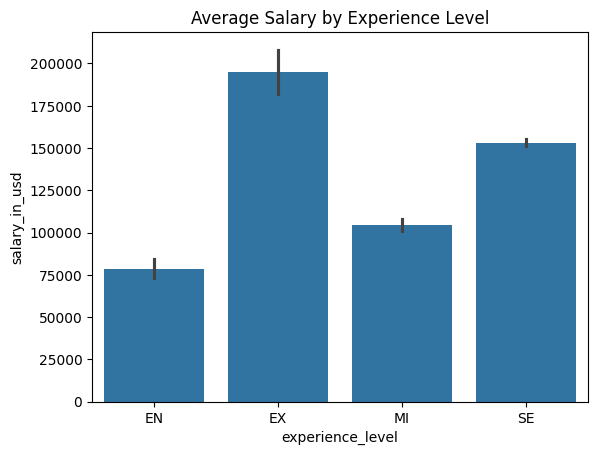

In [5]:
# Bar plot for experience level
sns.barplot(x='experience_level', y='salary_in_usd', data=df)
plt.title('Average Salary by Experience Level')
plt.show()


<h2>🧹 Part 3: Data Preprocessing for Linear Regression</h2>
We will predict salary_in_usd using only numerical or encoded categorical features.

<h3>Steps:</h3>
<ul>
<li>Select features: work_year, experience_level, and optionally job_title (you decide!)</li>
<li>Encode categorical variables (experience_level) using LabelEncoder or pd.get_dummies()</li>
<li>Define X (features) and y (target = salary_in_usd)</li></ul>
<p><b>⚠️ Important:</b>Do NOT include salary, salary_currency, or salary_in_usd in your features!</p>

In [6]:
# Encode experience_level, employment_type, company_size
le_exp = LabelEncoder()
le_emp = LabelEncoder()
le_company = LabelEncoder()

df['experience_level_encoded'] = le_exp.fit_transform(df['experience_level'])
df['employment_type_encoded'] = le_emp.fit_transform(df['employment_type'])
df['company_size_encoded'] = le_company.fit_transform(df['company_size'])

# Choose your features
features = ['work_year', 'experience_level_encoded', 
            'employment_type_encoded', 'company_size_encoded']

X = df[features]
y = df['salary_in_usd']

# But remember: too many categories can hurt performance

X.head()

,work_year,experience_level_encoded,employment_type_encoded,company_size_encoded
0,2023,0,2,0
1,2023,0,2,0
2,2023,0,2,0
3,2023,0,2,0
4,2023,0,2,0


<h2>📈 Part 4: Train a Linear Regression Model</h2>

In [7]:

# Split data into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train the model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate
print(f"R² Score: {r2_score(y_test, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}")

R² Score: 0.15
RMSE: 59152.96


<h2>🔮 Part 5: Predict 2024 Salaries</h2>
<p>Now, create a small DataFrame for <b>2024</b> with different experience levels and predict their salaries.</p>

Use the same encoding as before!

In [8]:
# Map experience levels to encoded values (check your LabelEncoder!)
# Example: EN=0, MI=1, SE=2, EX=3 (confirm with `le.classes_`)

print("Experience Level Encoding:", le_exp.classes_)
print("Employment Type Encoding:", le_emp.classes_)
print("Company Size Encoding:", le_company.classes_)


future_data = pd.DataFrame({
    'work_year': [2024, 2024, 2024, 2024],
    'experience_level_encoded': le_exp.transform(['EN', 'MI', 'SE', 'EX']),
    'employment_type_encoded': le_emp.transform(['FT', 'FT', 'FT', 'FT']),
    'company_size_encoded': le_company.transform(['M', 'M', 'M', 'M'])
})


# Predict
predicted_salaries = model.predict(future_data)

# Display results
results = pd.DataFrame({
    'Experience Level': ['Entry', 'Mid-Level', 'Senior', 'Executive'],
    'Predicted 2024 Salary (USD)': predicted_salaries.round(2)
})

results

Experience Level Encoding: ['EN' 'EX' 'MI' 'SE']
Employment Type Encoding: ['CT' 'FL' 'FT' 'PT']
Company Size Encoding: ['L' 'M' 'S']


,Experience Level,Predicted 2024 Salary (USD)
0,Entry,111702.91
1,Mid-Level,152468.46
2,Senior,172851.23
3,Executive,132085.69


<h2>📝 Part 6: Reflection (Answer in a Markdown Cell)</h2>
<ul>
<li>Does your model make reasonable predictions? Why or why not?</li>
<li>What are the limitations of using only work_year and experience_level?</li>
<li>How could you improve this model? (Think: more features, better encoding, etc.)</li>
<li>Why is <b>R² not enough </b>to trust your predictions?</li></ul>
<p>💡 Remember: Linear regression assumes a <b>linear trend</b>—but real salaries may grow non-linearly!</p>

<h2>Part 6: Reflection</h2>
<h3>1. Does your model make reasonable predictions? Why or why not?</h3>
Yeah, I think the model makes sense because it shows salaries going up as experience levels go up, which is pretty much what happens in real life. But the predictions aren't super accurate since it's only using a few bits of info. Salaries depend on tons of other stuff, so with just that limited data, it can only give a rough idea of the trend, not spot-on numbers.

<h3>2. What are the limitations of using only work_year and experience_level?</h3>
Yeah, so the big downside of just using work_year and experience_level is that it ignores a bunch of other stuff that matters. Like, salaries can totally depend on things like your job title, how big the company is, where you're located, and even the type of employment. Since those aren't factored in, the model ends up being way too basic and can't really explain why some people get paid more than others.

<h3>3. How could you improve this model?</h3>
Yeah, to make the model better, I'd throw in more key variables like job role, company size, and work location. Adding those extra features would give it way more info to really get what influences salary, helping it spit out more useful and accurate predictions.

<h3>4. Why is R² not enough to trust your predictions?</h3>
 R² just shows how well the model fits the data it was trained on. But even if it's super high, the model could still suck when you try it on new stuff. That means we can't just trust R² by itself—we gotta check how it actually does with real predictions.

<h2>📤 Submission Instructions</h2>
<ul>
<li>Save this notebook as: LastName_FirstName_SalaryPrediction.ipynb</li>
<li>Ensure all code runs without errors</li>
<li>Include your answers to the reflection questions</li>
<li>Submit via [your LMS/email/etc.]</li></ul>
Good luck! 🚀